# Train Model — Spark MLlib

| # | Dữ liệu | Model |
|---|----------|-------|
| 1 | Raw | Logistic Regression |
| 2 | Raw | Random Forest |
| 3 | Raw | GBT |
| 4 | Processed + Weight | Logistic Regression |
| 5 | Processed + Weight | Random Forest |
| 6 | Processed + Weight | GBT |
| 7 | Processed (no weight) | Logistic Regression |
| 8 | Processed (no weight) | Random Forest |
| 9 | Processed (no weight) | GBT |

---

## Setup

In [16]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("FraudDetection_Training") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version)

Spark version: 4.1.1


---
## Load dữ liệu

In [17]:
train_raw = spark.read.parquet("models/preprocessing/train_raw.parquet")
test_raw = spark.read.parquet("models/preprocessing/test_raw.parquet")
train_processed = spark.read.parquet("models/preprocessing/train_processed.parquet")
test_processed = spark.read.parquet("models/preprocessing/test_processed.parquet")

print("RAW:")
print(f"  Train: {train_raw.count():,} dòng, {len(train_raw.columns)} cột")
print(f"  Test:  {test_raw.count():,} dòng")
print(f"  Cột: {train_raw.columns}")

print("\nPROCESSED:")
print(f"  Train: {train_processed.count():,} dòng, {len(train_processed.columns)} cột")
print(f"  Test:  {test_processed.count():,} dòng")
print(f"  Cột: {train_processed.columns}")

RAW:
  Train: 1,296,675 dòng, 15 cột
  Test:  555,719 dòng
  Cột: ['merchant', 'category', 'amt', 'gender', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']

PROCESSED:
  Train: 1,296,675 dòng, 15 cột
  Test:  555,719 dòng
  Cột: ['merchant', 'category', 'amt', 'gender', 'city', 'state', 'city_pop', 'job', 'is_fraud', 'hour', 'day_of_week', 'month', 'age', 'distance_km', 'weight']


---
## Tạo Pipeline

In [18]:
raw_cat_ohe = ["category", "gender", "state"]
raw_cat_idx = ["merchant", "city", "job"]

raw_indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
                for c in raw_cat_ohe + raw_cat_idx]
raw_encoders = [OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_ohe")
                for c in raw_cat_ohe]

raw_numeric = ["amt", "zip", "lat", "long", "city_pop", "unix_time", "merch_lat", "merch_long"]
raw_ohe_cols = [f"{c}_ohe" for c in raw_cat_ohe]
raw_idx_cols = [f"{c}_idx" for c in raw_cat_idx]

raw_assembler = VectorAssembler(
    inputCols=raw_numeric + raw_idx_cols + raw_ohe_cols,
    outputCol="features", handleInvalid="keep")

raw_pipeline = Pipeline(stages=raw_indexers + raw_encoders + [raw_assembler])

proc_cat_ohe = ["category", "gender", "state"]
proc_cat_idx = ["merchant", "city", "job"]

proc_indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
                 for c in proc_cat_ohe + proc_cat_idx]
proc_encoders = [OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_ohe")
                 for c in proc_cat_ohe]

proc_numeric = ["amt", "city_pop", "hour", "day_of_week", "month", "age", "distance_km"]
proc_ohe_cols = [f"{c}_ohe" for c in proc_cat_ohe]
proc_idx_cols = [f"{c}_idx" for c in proc_cat_idx]

proc_assembler = VectorAssembler(
    inputCols=proc_numeric + proc_idx_cols + proc_ohe_cols,
    outputCol="features_raw", handleInvalid="keep")
proc_scaler = StandardScaler(inputCol="features_raw", outputCol="features", withStd=True, withMean=False)

proc_pipeline = Pipeline(stages=proc_indexers + proc_encoders + [proc_assembler, proc_scaler])

print("Raw pipeline:", len(raw_pipeline.getStages()), "stages")
print("Processed pipeline:", len(proc_pipeline.getStages()), "stages")

Raw pipeline: 10 stages
Processed pipeline: 11 stages


---
## Helper Functions

In [19]:
def evaluate_model(predictions, model_name="Model"):
    tp = predictions.filter((F.col("prediction") == 1) & (F.col("is_fraud") == 1)).count()
    fp = predictions.filter((F.col("prediction") == 1) & (F.col("is_fraud") == 0)).count()
    fn = predictions.filter((F.col("prediction") == 0) & (F.col("is_fraud") == 1)).count()
    tn = predictions.filter((F.col("prediction") == 0) & (F.col("is_fraud") == 0)).count()

    total = tp + fp + fn + tn
    accuracy = (tp + tn) / total if total > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    auc_roc = BinaryClassificationEvaluator(
        labelCol="is_fraud", rawPredictionCol="rawPrediction", metricName="areaUnderROC"
    ).evaluate(predictions)

    auc_pr = BinaryClassificationEvaluator(
        labelCol="is_fraud", rawPredictionCol="rawPrediction", metricName="areaUnderPR"
    ).evaluate(predictions)

    metrics = {
        "Model": model_name,
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-Score": round(f1, 4),
        "AUC-ROC": round(auc_roc, 4),
        "AUC-PR": round(auc_pr, 4),
    }
    cm = {"TP": tp, "FP": fp, "FN": fn, "TN": tn}
    return metrics, cm

def print_results(metrics, cm):
    for k, v in metrics.items():
        if k != "Model":
            print(f"  {k}: {v}")
    print(f"  CM: TP={cm['TP']:,}  FP={cm['FP']:,}  FN={cm['FN']:,}  TN={cm['TN']:,}")

---
## CrossValidator — 9 Cases

In [21]:
def create_model(model_name, weight_col=None):
    if model_name == "Logistic Regression":
        m = LogisticRegression(featuresCol="features", labelCol="is_fraud", maxIter=100, regParam=0.01)
    elif model_name == "Random Forest":
        m = RandomForestClassifier(featuresCol="features", labelCol="is_fraud", numTrees=100, maxDepth=10, maxBins=1000, seed=42)
    else:
        m = GBTClassifier(featuresCol="features", labelCol="is_fraud", maxIter=100, maxDepth=5, maxBins=1000, seed=42)
    if weight_col:
        m.setWeightCol(weight_col)
    return m

model_names = ["Logistic Regression", "Random Forest", "GBT"]

evaluator = BinaryClassificationEvaluator(
    labelCol="is_fraud", rawPredictionCol="rawPrediction", metricName="areaUnderPR")

datasets = {
    "Raw": {
        "train": train_raw,
        "test": test_raw,
        "pipeline": raw_pipeline,
        "weight_col": None,
    },
    "Processed+Weight": {
        "train": train_processed,
        "test": test_processed,
        "pipeline": proc_pipeline,
        "weight_col": "weight",
    },
    "Processed": {
        "train": train_processed,
        "test": test_processed,
        "pipeline": proc_pipeline,
        "weight_col": None,
    },
}

print(f"{len(datasets)} datasets × {len(model_names)} models = {len(datasets)*len(model_names)} cases, 5-fold CV")

Chuẩn bị: 3 datasets × 3 models = 9 cases
CrossValidator: 5-fold → tổng 45 lần train


In [22]:
cv_results = {}

for data_name, data_config in datasets.items():
    train_data = data_config["train"]
    test_data = data_config["test"]
    pipeline = data_config["pipeline"]
    weight_col = data_config["weight_col"]

    for model_name in model_names:
        case_name = f"{model_name} ({data_name})"
        print(f"\n{'='*60}")
        print(f"Training: {case_name}")
        print(f"{'='*60}")

        model = create_model(model_name, weight_col)
        full_cv_pipeline = Pipeline(stages=pipeline.getStages() + [model])

        paramGrid = ParamGridBuilder().build()
        cv = CrossValidator(
            estimator=full_cv_pipeline,
            estimatorParamMaps=paramGrid,
            evaluator=evaluator,
            numFolds=5,
            seed=42
        )

        cv_model = cv.fit(train_data)
        predictions = cv_model.transform(test_data)

        metrics, cm = evaluate_model(predictions, case_name)
        print_results(metrics, cm)
        print(f"  CV avg AUC-PR: {np.mean(cv_model.avgMetrics):.4f}")

        cv_results[case_name] = {
            "metrics": metrics,
            "cm": cm,
            "cv_model": cv_model,
            "predictions": predictions,
            "cv_score": np.mean(cv_model.avgMetrics),
        }
        all_results.append(metrics)
        all_cms[case_name] = cm

print(f"\n\nHoàn tất {len(cv_results)} cases!")


Training: Logistic Regression (Raw)


  Accuracy: 0.9957
  Precision: 0.0
  Recall: 0.0
  F1-Score: 0
  AUC-ROC: 0.8374
  AUC-PR: 0.1536
  CM: TP=0  FP=225  FN=2,145  TN=553,349
  CV avg AUC-PR: 0.2174

Training: Random Forest (Raw)


  Accuracy: 0.9961
  Precision: 1.0
  Recall: 0.0005
  F1-Score: 0.0009
  AUC-ROC: 0.9291
  AUC-PR: 0.4734
  CM: TP=1  FP=0  FN=2,144  TN=553,574
  CV avg AUC-PR: 0.6945

Training: GBT (Raw)


  Accuracy: 0.9969
  Precision: 0.6527
  Recall: 0.4354
  F1-Score: 0.5224
  AUC-ROC: 0.8941
  AUC-PR: 0.4985
  CM: TP=934  FP=497  FN=1,211  TN=553,077
  CV avg AUC-PR: 0.7360

Training: Logistic Regression (Processed+Weight)


  Accuracy: 0.849
  Precision: 0.0185
  Recall: 0.7324
  F1-Score: 0.0361
  AUC-ROC: 0.8652
  AUC-PR: 0.1168
  CM: TP=1,571  FP=83,331  FN=574  TN=470,243
  CV avg AUC-PR: 0.1669

Training: Random Forest (Processed+Weight)


  Accuracy: 0.9611
  Precision: 0.0827
  Recall: 0.8979
  F1-Score: 0.1514
  AUC-ROC: 0.9763
  AUC-PR: 0.4984
  CM: TP=1,926  FP=21,375  FN=219  TN=532,199
  CV avg AUC-PR: 0.6366

Training: GBT (Processed+Weight)


  Accuracy: 0.9723
  Precision: 0.1182
  Recall: 0.9566
  F1-Score: 0.2104
  AUC-ROC: 0.9948
  AUC-PR: 0.6901
  CM: TP=2,052  FP=15,312  FN=93  TN=538,262
  CV avg AUC-PR: 0.7714

Training: Logistic Regression (Processed)


  Accuracy: 0.9961
  Precision: 0
  Recall: 0.0
  F1-Score: 0
  AUC-ROC: 0.829
  AUC-PR: 0.2019
  CM: TP=0  FP=0  FN=2,145  TN=553,574
  CV avg AUC-PR: 0.2703

Training: Random Forest (Processed)


  Accuracy: 0.9965
  Precision: 1.0
  Recall: 0.0862
  F1-Score: 0.1588
  AUC-ROC: 0.9746
  AUC-PR: 0.6807
  CM: TP=185  FP=0  FN=1,960  TN=553,574
  CV avg AUC-PR: 0.7488

Training: GBT (Processed)


  Accuracy: 0.9982
  Precision: 0.8847
  Recall: 0.6084
  F1-Score: 0.721
  AUC-ROC: 0.9882
  AUC-PR: 0.7824
  CM: TP=1,305  FP=170  FN=840  TN=553,404
  CV avg AUC-PR: 0.8348


Hoàn tất 9 cases!


---
## So sánh tổng hợp

In [23]:
results_df = pd.DataFrame(all_results)
results_df = results_df.set_index("Model")
print(results_df.to_string())

                                        Accuracy  Precision  Recall  F1-Score  AUC-ROC  AUC-PR
Model                                                                                         
Baseline (all non-fraud)                  0.9961     0.0000  0.0000    0.0000   0.5000  0.0039
Logistic Regression (Raw)                 0.9957     0.0000  0.0000    0.0000   0.8374  0.1536
Random Forest (Raw)                       0.9961     1.0000  0.0005    0.0009   0.9291  0.4734
GBT (Raw)                                 0.9969     0.6527  0.4354    0.5224   0.8941  0.4985
Logistic Regression (Processed+Weight)    0.8490     0.0185  0.7324    0.0361   0.8652  0.1168
Random Forest (Processed+Weight)          0.9611     0.0827  0.8979    0.1514   0.9763  0.4984
GBT (Processed+Weight)                    0.9723     0.1182  0.9566    0.2104   0.9948  0.6901
Logistic Regression (Processed)           0.9961     0.0000  0.0000    0.0000   0.8290  0.2019
Random Forest (Processed)                 0.9965  

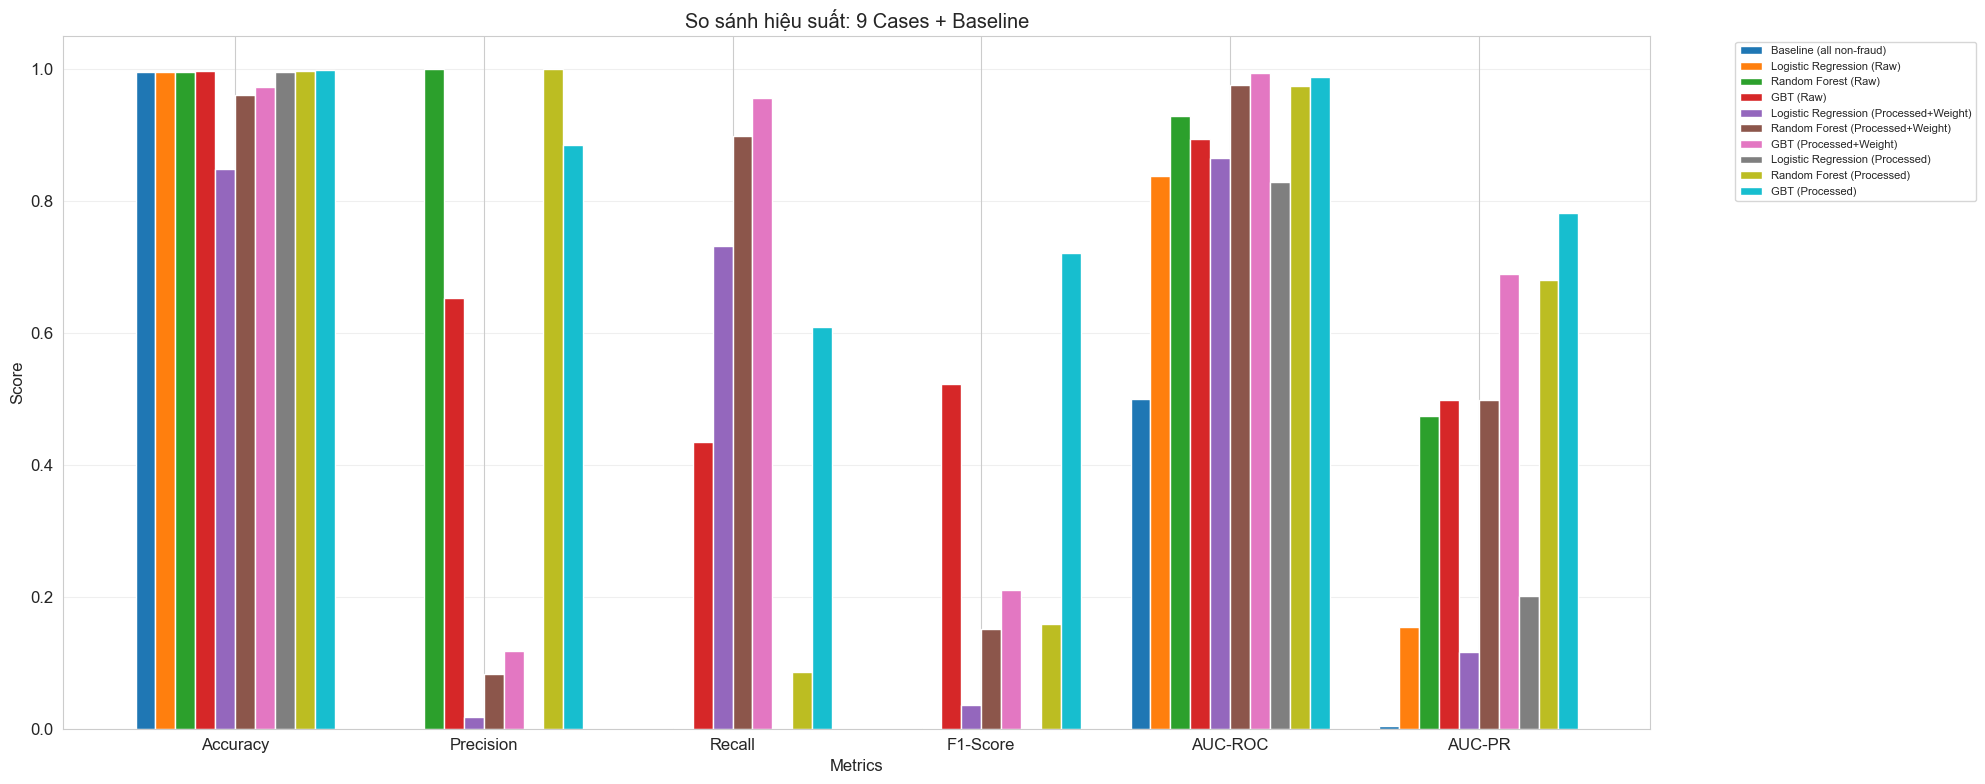

In [ ]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC", "AUC-PR"]
models_list = results_df.index.tolist()
x = np.arange(len(metrics_to_plot))
width = 0.08

fig, ax = plt.subplots(figsize=(20, 8))
for i, model in enumerate(models_list):
    values = [results_df.loc[model, m] for m in metrics_to_plot]
    ax.bar(x + i * width, values, width, label=model)

ax.set_xlabel("Metrics")
ax.set_ylabel("Score")
ax.set_title("So sánh hiệu suất: 9 Cases + Baseline")
ax.set_xticks(x + width * (len(models_list) - 1) / 2)
ax.set_xticklabels(metrics_to_plot)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
print("\n=== SO SÁNH RAW vs PROCESSED (không weight) ===")
print(f"{'Model':<25} {'Metric':<10} {'Raw':>8} {'Processed':>10} {'Δ':>8}")
print("-" * 65)
for model_name in ["Logistic Regression", "Random Forest", "GBT"]:
    raw_m = cv_results[f"{model_name} (Raw)"]["metrics"]
    proc_m = cv_results[f"{model_name} (Processed)"]["metrics"]
    for metric in ["Recall", "F1-Score", "AUC-PR"]:
        delta = proc_m[metric] - raw_m[metric]
        sign = "+" if delta > 0 else ""
        print(f"{model_name:<25} {metric:<10} {raw_m[metric]:>8.4f} {proc_m[metric]:>10.4f} {sign}{delta:>7.4f}")
    print()

print("\n=== SO SÁNH CÓ vs KHÔNG CLASS WEIGHT ===")
print(f"{'Model':<25} {'Metric':<10} {'No Weight':>10} {'Weight':>8} {'Δ':>8}")
print("-" * 65)
for model_name in ["Logistic Regression", "Random Forest", "GBT"]:
    no_w = cv_results[f"{model_name} (Processed)"]["metrics"]
    w = cv_results[f"{model_name} (Processed+Weight)"]["metrics"]
    for metric in ["Recall", "F1-Score", "AUC-PR"]:
        delta = w[metric] - no_w[metric]
        sign = "+" if delta > 0 else ""
        print(f"{model_name:<25} {metric:<10} {no_w[metric]:>10.4f} {w[metric]:>8.4f} {sign}{delta:>7.4f}")
    print()


=== SO SÁNH RAW vs PROCESSED (không weight) ===
Model                     Metric          Raw  Processed        Δ
-----------------------------------------------------------------
Logistic Regression       Recall       0.0000     0.0000  0.0000
Logistic Regression       F1-Score     0.0000     0.0000  0.0000
Logistic Regression       AUC-PR       0.1536     0.2019 + 0.0483

Random Forest             Recall       0.0005     0.0862 + 0.0857
Random Forest             F1-Score     0.0009     0.1588 + 0.1579
Random Forest             AUC-PR       0.4734     0.6807 + 0.2073

GBT                       Recall       0.4354     0.6084 + 0.1730
GBT                       F1-Score     0.5224     0.7210 + 0.1986
GBT                       AUC-PR       0.4985     0.7824 + 0.2839


=== SO SÁNH CÓ vs KHÔNG CLASS WEIGHT ===
Model                     Metric      No Weight   Weight        Δ
-----------------------------------------------------------------
Logistic Regression       Recall         0.0000   

In [45]:
best_case = max(cv_results.items(), key=lambda x: x[1]["metrics"]["AUC-PR"])
best_name = best_case[0]
best_metrics = best_case[1]["metrics"]
best_cv_model = best_case[1]["cv_model"]
best_predictions = best_case[1]["predictions"]

print(f"Model tốt nhất: {best_name}")
print(f"  AUC-PR:   {best_metrics['AUC-PR']}")
print(f"  F1-Score: {best_metrics['F1-Score']}")
print(f"  Recall:   {best_metrics['Recall']}")

Model tốt nhất: GBT (Processed)
  AUC-PR:   0.7824
  F1-Score: 0.721
  Recall:   0.6084


---
## Feature Importance

Lấy 77 feature names từ 'features_raw' metadata
Số importances từ model: 77

=== Feature Importance (chi tiết, top 15) ===
                   Feature  Importance
  category_ohe_grocery_pos    0.166320
                       amt    0.155361
                       age    0.142611
                      hour    0.118013
category_ohe_gas_transport    0.105987
                  city_idx    0.046973
              gender_ohe_F    0.041090
              merchant_idx    0.035217
     category_ohe_misc_net    0.033579
                  city_pop    0.032109
 category_ohe_shopping_net    0.028639
 category_ohe_shopping_pos    0.023316
    category_ohe_kids_pets    0.017998
              gender_ohe_M    0.010724
                   job_idx    0.007739

=== Feature Importance (gom nhóm) ===
    Feature  Importance
   category    0.400917
        amt    0.155361
        age    0.142611
       hour    0.118013
     gender    0.051813
       city    0.046973
   merchant    0.035217
   city_pop    0.03210

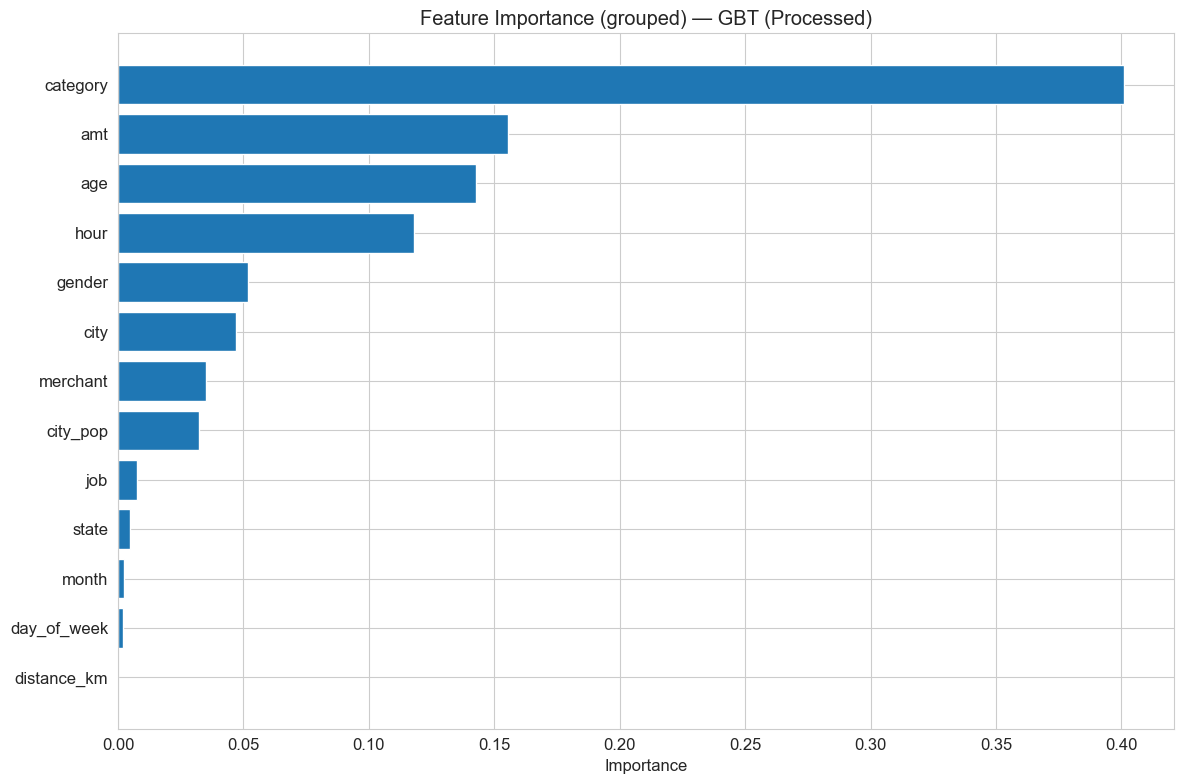

In [46]:
best_pipeline_model = best_cv_model.bestModel
best_classifier = best_pipeline_model.stages[-1]

# Lấy tên feature từ metadata
from pyspark.ml import PipelineModel
from pyspark.ml.feature import VectorAssembler, StandardScaler

pre_stages = best_pipeline_model.stages[:-1]
pre_pipeline = PipelineModel(stages=pre_stages)

if "Raw" in best_name:
    sample_df = test_raw.limit(1)
else:
    sample_df = test_processed.limit(1)

transformed = pre_pipeline.transform(sample_df)

# Tìm vector column có metadata (features hoặc features_raw)
feature_names = None
for col_name in ["features_raw", "features"]:
    if col_name in transformed.columns:
        meta = transformed.schema[col_name].metadata
        if "ml_attr" in meta and "attrs" in meta["ml_attr"]:
            attrs = sorted(
                (attr["idx"], attr["name"]) 
                for attr_group in meta["ml_attr"]["attrs"].values()
                for attr in attr_group
            )
            feature_names = [name for idx, name in attrs]
            print(f"Lấy {len(feature_names)} feature names từ '{col_name}' metadata")
            break

if feature_names is None:
    # Fallback: dùng inputCols của VectorAssembler
    assembler = [s for s in best_pipeline_model.stages if isinstance(s, VectorAssembler)][0]
    feature_names = list(assembler.getInputCols())
    print(f"Fallback: {len(feature_names)} input cols từ VectorAssembler")

if hasattr(best_classifier, "featureImportances"):
    importances = best_classifier.featureImportances.toArray()
    print(f"Số importances từ model: {len(importances)}")
    
    # Nếu vẫn lệch → dùng feature_0, feature_1...
    if len(feature_names) != len(importances):
        print(f"⚠ Lệch: {len(feature_names)} names vs {len(importances)} importances → dùng index")
        feature_names = [f"feature_{i}" for i in range(len(importances))]

    fi_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=False)

    # Gom nhóm: category_ohe_X → category, gender_ohe_X → gender, state_ohe_X → state
    def get_group(name):
        if "_ohe_" in name:
            return name.split("_ohe_")[0].replace("_ohe", "")
        if name.endswith("_idx"):
            return name.replace("_idx", "")
        return name
    
    fi_df["Group"] = fi_df["Feature"].apply(get_group)
    fi_grouped = fi_df.groupby("Group")["Importance"].sum().sort_values(ascending=False).reset_index()
    fi_grouped.columns = ["Feature", "Importance"]

    print(f"\n=== Feature Importance (chi tiết, top 15) ===")
    print(fi_df[["Feature", "Importance"]].head(15).to_string(index=False))
    print(f"\n=== Feature Importance (gom nhóm) ===")
    print(fi_grouped.to_string(index=False))

    fig, ax = plt.subplots(figsize=(12, 8))
    top_fi = fi_grouped
    ax.barh(range(len(top_fi)), top_fi["Importance"].values)
    ax.set_yticks(range(len(top_fi)))
    ax.set_yticklabels(top_fi["Feature"].values)
    ax.invert_yaxis()
    ax.set_xlabel("Importance")
    ax.set_title(f"Feature Importance (grouped) — {best_name}")
    plt.tight_layout()
    plt.show()

elif hasattr(best_classifier, "coefficients"):
    coeffs = best_classifier.coefficients.toArray()
    if len(feature_names) != len(coeffs):
        feature_names = [f"feature_{i}" for i in range(len(coeffs))]
    
    fi_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": np.abs(coeffs)
    }).sort_values("Coefficient", ascending=False)
    print("LR Coefficients (|value|, top 15):")
    print(fi_df.head(15).to_string(index=False))


---
## Hyperparameter Tuning

In [ ]:
if "Random Forest" in best_name:
    tuning_classifier = RandomForestClassifier(
        featuresCol="features", labelCol="is_fraud", maxBins=1000, seed=42)
    if "Weight" in best_name:
        tuning_classifier.setWeightCol("weight")
    paramGrid = ParamGridBuilder() \
        .addGrid(tuning_classifier.numTrees, [50, 100, 200]) \
        .addGrid(tuning_classifier.maxDepth, [5, 10, 15]) \
        .build()
elif "GBT" in best_name:
    tuning_classifier = GBTClassifier(
        featuresCol="features", labelCol="is_fraud", maxBins=1000, seed=42)
    if "Weight" in best_name:
        tuning_classifier.setWeightCol("weight")
    paramGrid = ParamGridBuilder() \
        .addGrid(tuning_classifier.maxIter, [50, 100, 150]) \
        .addGrid(tuning_classifier.maxDepth, [3, 5, 7]) \
        .build()
else:
    tuning_classifier = LogisticRegression(
        featuresCol="features", labelCol="is_fraud")
    if "Weight" in best_name:
        tuning_classifier.setWeightCol("weight")
    paramGrid = ParamGridBuilder() \
        .addGrid(tuning_classifier.regParam, [0.001, 0.01, 0.1]) \
        .addGrid(tuning_classifier.elasticNetParam, [0.0, 0.5, 1.0]) \
        .build()

if "Raw" in best_name:
    tuning_pipeline = Pipeline(stages=raw_pipeline.getStages() + [tuning_classifier])
    tuning_train = train_raw
    tuning_test = test_raw
else:
    tuning_pipeline = Pipeline(stages=proc_pipeline.getStages() + [tuning_classifier])
    tuning_train = train_processed
    tuning_test = test_processed

cv_tuning = CrossValidator(
    estimator=tuning_pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=5,
    seed=42
)

print(f"Tuning {best_name}: {len(paramGrid)} combinations × 5 folds = {len(paramGrid)*5} fits...")
tuned_cv_model = cv_tuning.fit(tuning_train)
tuned_pred = tuned_cv_model.transform(tuning_test)

tuned_metrics, tuned_cm = evaluate_model(tuned_pred, f"{best_name} (Tuned)")
print("\nSau tuning:")
print_results(tuned_metrics, tuned_cm)

Tuning GBT (Processed): 9 combinations × 5 folds = 45 fits...


In [54]:
compare_data = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC", "AUC-PR"],
    "Before": [best_metrics[m] for m in ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC", "AUC-PR"]],
    "After": [tuned_metrics[m] for m in ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC", "AUC-PR"]],
}
compare_df = pd.DataFrame(compare_data)
compare_df["Δ"] = compare_df["After"] - compare_df["Before"]
print(compare_df.to_string(index=False))

   Metric  Before  After       Δ
 Accuracy  0.9982 0.9984  0.0002
Precision  0.8847 0.8761 -0.0086
   Recall  0.6084 0.6923  0.0839
 F1-Score  0.7210 0.7734  0.0524
  AUC-ROC  0.9882 0.9935  0.0053
   AUC-PR  0.7824 0.8320  0.0496


In [55]:
tuned_classifier = tuned_cv_model.bestModel.stages[-1]

print(f"Best hyperparameters:")
if hasattr(tuned_classifier, "getNumTrees"):
    print(f"  numTrees: {tuned_classifier.getNumTrees}")
    print(f"  maxDepth: {tuned_classifier.getMaxDepth()}")
elif hasattr(tuned_classifier, "getMaxIter"):
    print(f"  maxIter: {tuned_classifier.getMaxIter()}")
    if hasattr(tuned_classifier, "getMaxDepth"):
        print(f"  maxDepth: {tuned_classifier.getMaxDepth()}")
if hasattr(tuned_classifier, "getRegParam"):
    print(f"  regParam: {tuned_classifier.getRegParam()}")
    print(f"  elasticNetParam: {tuned_classifier.getElasticNetParam()}")

Best hyperparameters:
  numTrees: 150
  maxDepth: 7


---
## Threshold Tuning

In [65]:
from pyspark.ml.functions import vector_to_array

train_pred = tuned_cv_model.transform(tuning_train)

if "probability" not in train_pred.columns:
    train_for_threshold = train_pred.withColumn(
        "prob_array", vector_to_array("rawPrediction")
    ).withColumn("fraud_score",
        1.0 / (1.0 + F.exp(-F.col("prob_array").getItem(1)))
    )
else:
    train_for_threshold = train_pred.withColumn(
        "fraud_score", vector_to_array("probability").getItem(1)
    )

# Predict trên TEST (chỉ dùng để đánh giá cuối)
if "probability" not in tuned_pred.columns:
    test_for_threshold = tuned_pred.withColumn(
        "prob_array", vector_to_array("rawPrediction")
    ).withColumn("fraud_score",
        1.0 / (1.0 + F.exp(-F.col("prob_array").getItem(1)))
    )
else:
    test_for_threshold = tuned_pred.withColumn(
        "fraud_score", vector_to_array("probability").getItem(1)
    )

# Tuning threshold trên TRAIN
thresholds = np.arange(0.1, 0.91, 0.05)
threshold_results = []

for t in thresholds:
    t_pred = train_for_threshold.withColumn(
        "pred_t",
        F.when(F.col("fraud_score") >= t, 1.0).otherwise(0.0)
    )
    tp = t_pred.filter((F.col("pred_t") == 1) & (F.col("is_fraud") == 1)).count()
    fp = t_pred.filter((F.col("pred_t") == 1) & (F.col("is_fraud") == 0)).count()
    fn = t_pred.filter((F.col("pred_t") == 0) & (F.col("is_fraud") == 1)).count()

    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0

    threshold_results.append({"Threshold": round(t, 2), "Precision": prec, "Recall": rec, "F1-Score": f1})

threshold_df = pd.DataFrame(threshold_results)
print("Threshold tuning (trên tập TRAIN):")
print(threshold_df.to_string(index=False))

Threshold tuning (trên tập TRAIN):
 Threshold  Precision   Recall  F1-Score
      0.10   0.737870 0.905675  0.813207
      0.15   0.817555 0.884759  0.849830
      0.20   0.868207 0.866240  0.867222
      0.25   0.904412 0.852118  0.877487
      0.30   0.927267 0.839062  0.880962
      0.35   0.943365 0.827738  0.881777
      0.40   0.957507 0.816547  0.881427
      0.45   0.968290 0.805489  0.879418
      0.50   0.975702 0.791767  0.874163
      0.55   0.980824 0.776845  0.866999
      0.60   0.985877 0.762590  0.859976
      0.65   0.989431 0.748335  0.852158
      0.70   0.993643 0.728884  0.840916
      0.75   0.995156 0.711564  0.829799
      0.80   0.997106 0.688649  0.814657
      0.85   0.998187 0.660272  0.794804
      0.90   0.999143 0.620970  0.765919


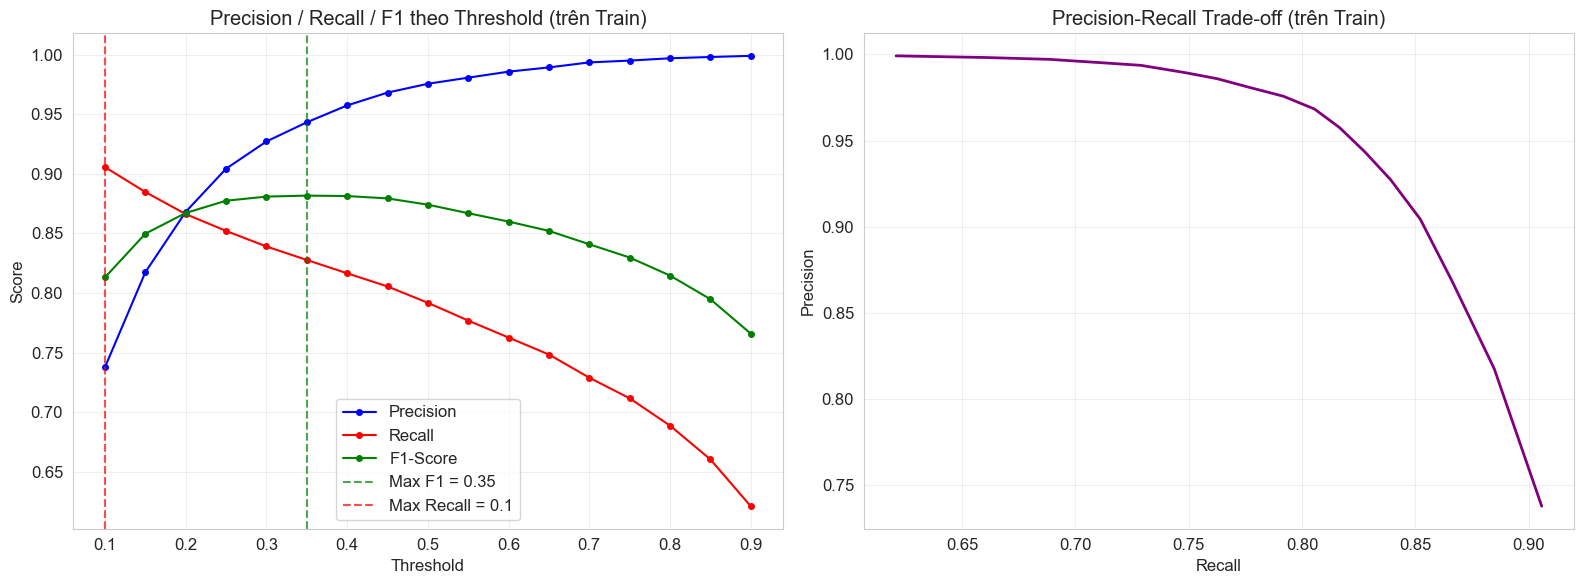


Chiến lược 1 — Max F1 (cân bằng): threshold = 0.35
  Precision: 0.9434
  Recall:    0.8277
  F1-Score:  0.8818

Chiến lược 2 — Max Recall (không bỏ sót fraud): threshold = 0.1
  Precision: 0.7379
  Recall:    0.9057
  F1-Score:  0.8132


In [71]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(threshold_df['Threshold'], threshold_df['Precision'], 'b-o', label='Precision', markersize=4)
axes[0].plot(threshold_df['Threshold'], threshold_df['Recall'], 'r-o', label='Recall', markersize=4)
axes[0].plot(threshold_df['Threshold'], threshold_df['F1-Score'], 'g-o', label='F1-Score', markersize=4)
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision / Recall / F1 theo Threshold (trên Train)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

f1_idx = threshold_df['F1-Score'].idxmax()
threshold_f1 = threshold_df.loc[f1_idx, 'Threshold']
axes[0].axvline(x=threshold_f1, color='green', linestyle='--', alpha=0.7, label=f'Max F1 = {threshold_f1}')

recall_candidates = threshold_df[threshold_df['Precision'] >= 0.5]
if len(recall_candidates) > 0:
    recall_idx = recall_candidates['Recall'].idxmax()
    threshold_recall = recall_candidates.loc[recall_idx, 'Threshold']
else:
    recall_idx = threshold_df['Recall'].idxmax()
    threshold_recall = threshold_df.loc[recall_idx, 'Threshold']
axes[0].axvline(x=threshold_recall, color='red', linestyle='--', alpha=0.7, label=f'Max Recall = {threshold_recall}')

axes[0].legend()

axes[1].plot(threshold_df['Recall'], threshold_df['Precision'], 'purple', linewidth=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Trade-off (trên Train)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nChiến lược 1 — Max F1 (cân bằng): threshold = {threshold_f1}")
print(f"  Precision: {threshold_df.loc[f1_idx, 'Precision']:.4f}")
print(f"  Recall:    {threshold_df.loc[f1_idx, 'Recall']:.4f}")
print(f"  F1-Score:  {threshold_df.loc[f1_idx, 'F1-Score']:.4f}")

print(f"\nChiến lược 2 — Max Recall (không bỏ sót fraud): threshold = {threshold_recall}")
print(f"  Precision: {threshold_df.loc[recall_idx, 'Precision']:.4f}")
print(f"  Recall:    {threshold_df.loc[recall_idx, 'Recall']:.4f}")
print(f"  F1-Score:  {threshold_df.loc[recall_idx, 'F1-Score']:.4f}")

In [72]:
print("=" * 60)
print("ĐÁNH GIÁ 2 CHIẾN LƯỢC TRÊN TẬP TEST")
print("=" * 60)

final_pred_f1 = test_for_threshold.withColumn(
    "prediction",
    F.when(F.col("fraud_score") >= threshold_f1, 1.0).otherwise(0.0)
)
metrics_f1, cm_f1 = evaluate_model(final_pred_f1, f"{best_name} (Max F1, t={threshold_f1})")
print(f"\nChiến lược 1 — Max F1 (threshold = {threshold_f1}):")
print_results(metrics_f1, cm_f1)

final_pred_recall = test_for_threshold.withColumn(
    "prediction",
    F.when(F.col("fraud_score") >= threshold_recall, 1.0).otherwise(0.0)
)
metrics_recall, cm_recall = evaluate_model(final_pred_recall, f"{best_name} (Max Recall, t={threshold_recall})")
print(f"\nChiến lược 2 — Max Recall (threshold = {threshold_recall}):")
print_results(metrics_recall, cm_recall)

compare = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-Score", "AUC-PR"],
    f"Max F1 (t={threshold_f1})": [metrics_f1[m] for m in ["Precision", "Recall", "F1-Score", "AUC-PR"]],
    f"Max Recall (t={threshold_recall})": [metrics_recall[m] for m in ["Precision", "Recall", "F1-Score", "AUC-PR"]],
})
print(f"\n{compare.to_string(index=False)}")

optimal_threshold = threshold_f1
final_pred = final_pred_f1
final_metrics = metrics_f1
final_cm = cm_f1

ĐÁNH GIÁ 2 CHIẾN LƯỢC TRÊN TẬP TEST



Chiến lược 1 — Max F1 (threshold = 0.35):
  Accuracy: 0.9984
  Precision: 0.8264
  Recall: 0.7259
  F1-Score: 0.7729
  AUC-ROC: 0.9935
  AUC-PR: 0.832
  CM: TP=1,557  FP=327  FN=588  TN=553,247



Chiến lược 2 — Max Recall (threshold = 0.1):
  Accuracy: 0.9972
  Precision: 0.5993
  Recall: 0.8261
  F1-Score: 0.6946
  AUC-ROC: 0.9935
  AUC-PR: 0.832
  CM: TP=1,772  FP=1,185  FN=373  TN=552,389

   Metric  Max F1 (t=0.35)  Max Recall (t=0.1)
Precision           0.8264              0.5993
   Recall           0.7259              0.8261
 F1-Score           0.7729              0.6946
   AUC-PR           0.8320              0.8320


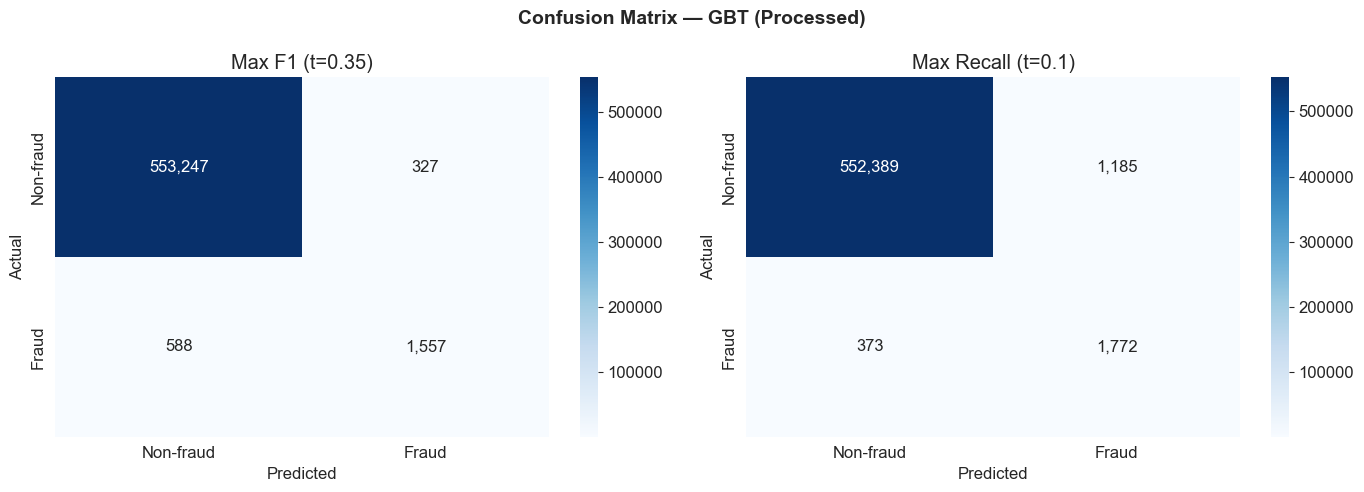

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (title, cm) in enumerate([
    (f"Max F1 (t={threshold_f1})", cm_f1),
    (f"Max Recall (t={threshold_recall})", cm_recall),
]):
    matrix = np.array([[cm["TN"], cm["FP"]], [cm["FN"], cm["TP"]]])
    sns.heatmap(matrix, annot=True, fmt=",d", cmap="Blues",
                xticklabels=["Non-fraud", "Fraud"],
                yticklabels=["Non-fraud", "Fraud"],
                ax=axes[idx])
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")
    axes[idx].set_title(title)

plt.suptitle(f"Confusion Matrix — {best_name}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Phân tích lỗi

In [74]:
fn_df = final_pred.filter((F.col("prediction") == 0) & (F.col("is_fraud") == 1))
fp_df = final_pred.filter((F.col("prediction") == 1) & (F.col("is_fraud") == 0))

print(f"False Negative (fraud bị bỏ sót): {fn_df.count():,}")
print(f"False Positive (non-fraud bị báo nhầm): {fp_df.count():,}")

False Negative (fraud bị bỏ sót): 588


False Positive (non-fraud bị báo nhầm): 327


In [75]:
print("=" * 60)
print("PHÂN TÍCH FALSE NEGATIVE (Fraud bị bỏ sót)")
print("=" * 60)

if fn_df.count() > 0:
    print(f"\nSố lượng: {fn_df.count():,}")

    print("\nPhân bố amount:")
    fn_df.select("amt").describe().show()

    print("Phân bố theo category:")
    fn_df.groupBy("category").count().orderBy(F.desc("count")).show(10)

    if "hour" in fn_df.columns:
        print("Phân bố theo giờ:")
        fn_df.groupBy("hour").count().orderBy("hour").show(24)

    if "merchant" in fn_df.columns:
        print("Top merchant bị bỏ sót:")
        fn_df.groupBy("merchant").count().orderBy(F.desc("count")).show(10)
else:
    print("Không có False Negative!")

PHÂN TÍCH FALSE NEGATIVE (Fraud bị bỏ sót)



Số lượng: 588

Phân bố amount:


+-------+------------------+
|summary|               amt|
+-------+------------------+
|  count|               588|
|   mean|110.24454081632659|
| stddev| 83.91393509337546|
|    min|              1.78|
|    max|            192.01|
+-------+------------------+

Phân bố theo category:


+--------------+-----+
|      category|count|
+--------------+-----+
| personal_care|   69|
|      misc_net|   68|
|  shopping_net|   61|
|     kids_pets|   58|
|health_fitness|   52|
|  shopping_pos|   52|
|   food_dining|   44|
|   grocery_pos|   39|
|          home|   37|
|        travel|   31|
+--------------+-----+
only showing top 10 rows
Phân bố theo giờ:


+----+-----+
|hour|count|
+----+-----+
|   0|   24|
|   1|   31|
|   2|   24|
|   3|   35|
|   4|    4|
|   5|    8|
|   6|    5|
|   7|    8|
|   8|    3|
|   9|    5|
|  10|    2|
|  11|    6|
|  12|    7|
|  13|    5|
|  14|    8|
|  15|   11|
|  16|   12|
|  17|    9|
|  18|   18|
|  19|   13|
|  20|   19|
|  21|   17|
|  22|  155|
|  23|  159|
+----+-----+

Top merchant bị bỏ sót:


+--------------------+-----+
|            merchant|count|
+--------------------+-----+
|    fraud_Schumm PLC|    4|
|fraud_Hilpert-Conroy|    4|
|fraud_Ziemann-Waters|    4|
|  fraud_Bednar Group|    4|
|fraud_Heathcote, ...|    4|
|fraud_Erdman-Schaden|    4|
|fraud_Swaniawski,...|    4|
|fraud_Dare, Caspe...|    4|
|fraud_Okuneva, Sc...|    4|
|fraud_Kihn, Abern...|    3|
+--------------------+-----+
only showing top 10 rows


In [76]:
print("=" * 60)
print("PHÂN TÍCH FALSE POSITIVE (Non-fraud bị báo nhầm)")
print("=" * 60)

if fp_df.count() > 0:
    print(f"\nSố lượng: {fp_df.count():,}")

    print("\nPhân bố amount:")
    fp_df.select("amt").describe().show()

    print("Phân bố theo category:")
    fp_df.groupBy("category").count().orderBy(F.desc("count")).show(10)
else:
    print("Không có False Positive!")

PHÂN TÍCH FALSE POSITIVE (Non-fraud bị báo nhầm)



Số lượng: 327

Phân bố amount:


+-------+-----------------+
|summary|              amt|
+-------+-----------------+
|  count|              327|
|   mean|157.2369113149848|
| stddev|68.28410001806706|
|    min|             1.05|
|    max|           192.01|
+-------+-----------------+

Phân bố theo category:


+-------------+-----+
|     category|count|
+-------------+-----+
| shopping_net|   75|
|  grocery_pos|   45|
|         home|   40|
| shopping_pos|   38|
|     misc_net|   33|
|     misc_pos|   26|
|entertainment|   25|
|gas_transport|   14|
|    kids_pets|    8|
|  food_dining|    6|
+-------------+-----+
only showing top 10 rows


---
## Lưu model

In [77]:
import os, shutil, json

output_dir = "models/best_model"
os.makedirs(output_dir, exist_ok=True)

model_path = f"{output_dir}/tuned_model"
if os.path.exists(model_path):
    shutil.rmtree(model_path)
tuned_cv_model.bestModel.save(model_path)
print(f"Đã lưu model: {model_path}")

model_info = {
    "best_case": best_name,
    "optimal_threshold": float(optimal_threshold),
    "final_metrics": {k: float(v) if isinstance(v, (int, float, np.floating)) else v
                      for k, v in final_metrics.items()},
    "all_9cases": {k: v["metrics"] for k, v in cv_results.items()},
}

with open(f"{output_dir}/model_info.json", "w") as f:
    json.dump(model_info, f, indent=2, ensure_ascii=False)
print(f"Đã lưu model info: {output_dir}/model_info.json")

Đã lưu model: models/best_model/tuned_model
Đã lưu model info: models/best_model/model_info.json


In [78]:
spark.stop()
